# SankhyaVox — Sanskrit Digit Recognition (0–99)

Two-model training pipeline: GMM-HMM on real recordings (Model A) and real + TTS synthetic data (Model B). The better-performing model on compound recognition is saved as the production artifact.

In [1]:
import subprocess, sys

PACKAGES = ["gTTS", "edge-tts", "hmmlearn", "imageio-ffmpeg"]

for pkg in PACKAGES:
    r = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                       capture_output=True, text=True)
    status = "ok" if r.returncode == 0 else f"FAILED: {r.stderr[:60]}"
    print(f"  {pkg}: {status}")

print("Packages ready.")
print("NOTE: hmmlearn is CPU-only. GPU accelerators provide no benefit here.")


  gTTS: ok
  edge-tts: ok
  hmmlearn: ok
  imageio-ffmpeg: ok
Packages ready.
NOTE: hmmlearn is CPU-only. GPU accelerators provide no benefit here.


## Step 1: Imports, Paths, Vocabulary

In [2]:
import os, sys, glob, warnings, tempfile, subprocess, time, json, shutil, zipfile
import numpy as np
import librosa
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings("ignore")

KAGGLE_INPUT = "/kaggle/input"
WORKING_DIR  = "/kaggle/working"

def find_dataset_root():
    for root, dirs, _files in os.walk(KAGGLE_INPUT):
        if "SankhyaVox_data" in dirs:
            return os.path.join(root, "SankhyaVox_data")
        if os.path.basename(root) == "SankhyaVox_data":
            return root
    return None

REAL_DATA_DIR = find_dataset_root()
if REAL_DATA_DIR is None:
    print("Dataset not found. Contents of /kaggle/input:")
    for item in os.listdir(KAGGLE_INPUT):
        print(f"  {item}/")
    raise RuntimeError("Add SankhyaVox_data under Data > Add Data and rerun.")
print(f"Dataset: {REAL_DATA_DIR}")

MODEL_A_DIR = os.path.join(WORKING_DIR, "model_A_real_only")
MODEL_B_DIR = os.path.join(WORKING_DIR, "model_B_real_synth")
BEST_DIR    = os.path.join(WORKING_DIR, "model_best")
OUTPUT_DIR  = os.path.join(WORKING_DIR, "outputs")
for d in [MODEL_A_DIR, MODEL_B_DIR, BEST_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

SAMPLE_RATE = 16000

VOCAB = [
    "shunya", "eka",  "dvi",    "tri",    "catur",
    "pancha", "shat", "sapta",  "ashta",  "nava",
    "dasha",  "vimsati", "shata",
]

DEVANAGARI = {
    "shunya":"शून्य", "eka":"एक",    "dvi":"द्वि",
    "tri":"त्रि",    "catur":"चतुर","pancha":"पञ्च",
    "shat":"षट",     "sapta":"सप्त","ashta":"अष्ट",
    "nava":"नव",     "dasha":"दश",  "vimsati":"विंशति",
    "shata":"शत",
}

TOKEN_TO_IDX = {t: i for i, t in enumerate(VOCAB)}
IDX_TO_TOKEN = {i: t for i, t in enumerate(VOCAB)}

print(f"Vocabulary: {len(VOCAB)} tokens")
for i, t in enumerate(VOCAB):
    print(f"  [{i:2d}] {t:10s}  {DEVANAGARI[t]}")
print(f"Sample rate: {SAMPLE_RATE} Hz")


Dataset: /kaggle/input/datasets/sujal056/real-data/SankhyaVox_data
Vocabulary: 13 tokens
  [ 0] shunya      शून्य
  [ 1] eka         एक
  [ 2] dvi         द्वि
  [ 3] tri         त्रि
  [ 4] catur       चतुर
  [ 5] pancha      पञ्च
  [ 6] shat        षट
  [ 7] sapta       सप्त
  [ 8] ashta       अष्ट
  [ 9] nava        नव
  [10] dasha       दश
  [11] vimsati     विंशति
  [12] shata       शत
Sample rate: 16000 Hz


## Step 2: Grammar (0–99)

In [3]:
UNITS = ["eka","dvi","tri","catur","pancha","shat","sapta","ashta","nava"]

def build_grammar():
    g = {}
    g[0] = ["shunya"]
    for i, u in enumerate(UNITS, 1):
        g[i] = [u]
    g[10] = ["dasha"]
    for i, u in enumerate(UNITS, 1):
        g[10 + i] = ["dasha", u]
    g[20] = ["vimsati"]
    for i, u in enumerate(UNITS, 1):
        g[20 + i] = ["vimsati", u]
    tens = {3:"tri",4:"catur",5:"pancha",6:"shat",7:"sapta",8:"ashta",9:"nava"}
    for d, mult in tens.items():
        base = d * 10
        g[base] = [mult, "dasha"]
        for i, u in enumerate(UNITS, 1):
            g[base + i] = [mult, "dasha", u]
    return g

GRAMMAR    = build_grammar()
SEQ_TO_INT = {tuple(seq): val for val, seq in GRAMMAR.items()}

def tokens_to_number(token_list):
    return SEQ_TO_INT.get(tuple(token_list), -1)

assert tokens_to_number(["shunya"])             == 0
assert tokens_to_number(["dasha", "pancha"])    == 15
assert tokens_to_number(["pancha", "dasha"])    == 50
assert tokens_to_number(["nava","dasha","nava"])== 99
assert len(GRAMMAR) == 100
print(f"Grammar: {len(GRAMMAR)} sequences verified.")
for n in [0, 10, 15, 50, 99]:
    print(f"  {n:3d} -> {GRAMMAR[n]}")


Grammar: 100 sequences verified.
    0 -> ['shunya']
   10 -> ['dasha']
   15 -> ['dasha', 'pancha']
   50 -> ['pancha', 'dasha']
   99 -> ['nava', 'dasha', 'nava']


## Step 3: Audio Utilities and MFCC Extraction

In [4]:
N_MFCC     = 13
N_FEATURES = 39
HOP_MS     = 10
WIN_MS     = 25

# Clip duration bounds used during real data loading.
# Below MIN: likely a silence fragment from over-splitting.
# Above MAX: likely an unsplit compound or recording error.
CLIP_MIN_MS = 80    # 80ms  — shortest plausible Sanskrit digit
CLIP_MAX_MS = 2500  # 2500ms — longest plausible single token

def load_audio(path, target_sr=SAMPLE_RATE):
    audio, sr = librosa.load(path, sr=target_sr, mono=True)
    return audio.astype("float32"), target_sr

def preprocess_audio(audio, sr):
    audio = audio - np.mean(audio)
    peak  = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak * 0.95
    return audio

def extract_mfcc(audio, sr=SAMPLE_RATE):
    hop = int(sr * HOP_MS / 1000)
    win = int(sr * WIN_MS / 1000)
    pre = np.append(audio[0], audio[1:] - 0.97 * audio[:-1])
    mfcc   = librosa.feature.mfcc(y=pre, sr=sr, n_mfcc=N_MFCC, hop_length=hop, n_fft=win)
    # mode='nearest' avoids ParameterError when n_frames < 9 (default mode='interp'
    # requires width <= n_frames; short VAD segments can produce as few as 5 frames).
    delta  = librosa.feature.delta(mfcc, mode='nearest')
    delta2 = librosa.feature.delta(mfcc, order=2, mode='nearest')
    features = np.vstack([mfcc, delta, delta2]).T
    mean = np.mean(features, axis=0, keepdims=True)
    std  = np.std( features, axis=0, keepdims=True) + 1e-8
    return ((features - mean) / std).astype("float32")

def count_vad_segments(audio, sr, top_db=28, min_dur_s=0.06):
    intervals = librosa.effects.split(
        audio, top_db=top_db,
        frame_length=int(sr * 0.025),
        hop_length=int(sr * 0.010),
    )
    min_s = int(min_dur_s * sr)
    return sum(1 for s, e in intervals if (e - s) >= min_s)

def split_by_silence(audio, sr, top_db=28, min_dur_s=0.15, max_dur_s=None):
    """
    Split a multi-repetition recording into individual word clips.
    Clips outside [CLIP_MIN_MS, CLIP_MAX_MS] are rejected.
    """
    intervals = librosa.effects.split(audio, top_db=top_db)
    clips = []
    min_s = int(min_dur_s * sr)
    min_b = int(CLIP_MIN_MS / 1000 * sr)
    max_b = int(CLIP_MAX_MS / 1000 * sr)
    for start, end in intervals:
        n = end - start
        if n >= min_s and n >= min_b and n <= max_b:
            clips.append((audio[start:end].copy(), sr))
    return clips

# Self-test
_d = np.random.randn(SAMPLE_RATE).astype("float32")
_f = extract_mfcc(_d)
assert _f.shape[1] == N_FEATURES
print(f"MFCC extractor: 1s audio -> {_f.shape} (frames x features). OK.")


MFCC extractor: 1s audio -> (101, 39) (frames x features). OK.


## Step 4: Load Real Recordings

S04 is excluded — its recordings are corrupted and mismatched. `CLIP_MIN_MS` / `CLIP_MAX_MS` filters reject fragments and overlong clips before they enter training.

In [5]:
SKIP_SPEAKERS = {"S04"}

speakers = sorted([
    d for d in os.listdir(REAL_DATA_DIR)
    if os.path.isdir(os.path.join(REAL_DATA_DIR, d))
    and d not in SKIP_SPEAKERS
])
print(f"Speakers: {speakers}")
if SKIP_SPEAKERS:
    print(f"Excluded: {SKIP_SPEAKERS}  (corrupted/mismatched recordings)")

real_audio = {tok: [] for tok in VOCAB}
rejected   = {tok: 0 for tok in VOCAB}

for spk in speakers:
    spk_dir = os.path.join(REAL_DATA_DIR, spk)
    print(f"\n  {spk}:")
    for tok in VOCAB:
        pattern = os.path.join(spk_dir, f"{spk}_{tok}_raw.*")
        matches = glob.glob(pattern) or glob.glob(os.path.join(spk_dir, f"{spk}_{tok}.*"))
        if not matches:
            print(f"    {tok:10s} - not found")
            continue
        try:
            audio, sr = load_audio(matches[0])
            audio = preprocess_audio(audio, sr)
            clips = split_by_silence(audio, sr, top_db=28, min_dur_s=0.15)
            if not clips:
                # Fallback: treat the whole file as one clip if it falls within bounds
                n = len(audio)
                if int(CLIP_MIN_MS/1000*sr) <= n <= int(CLIP_MAX_MS/1000*sr):
                    clips = [(audio, sr)]
                    print(f"    {tok:10s} - 1 clip (no silence split)")
                else:
                    print(f"    {tok:10s} - 0 clips (file outside duration bounds, skipped)")
                    continue
            real_audio[tok].extend(clips)
            print(f"    {tok:10s} - {len(clips)} clips")
        except Exception as e:
            print(f"    {tok:10s} - error: {e}")

print("\n  Summary:")
total = 0
for tok in VOCAB:
    n = len(real_audio[tok])
    total += n
    flag = "  LOW" if n < 20 else ""
    print(f"  {tok:12s}  {n:4d}{flag}")
print(f"  {'TOTAL':12s}  {total:4d}")
if total < 100:
    print("WARNING: very few clips — check file names and SKIP_SPEAKERS.")


Speakers: ['S01', 'S02', 'S03', 'S05']
Excluded: {'S04'}  (corrupted/mismatched recordings)

  S01:
    shunya     - 12 clips
    eka        - 13 clips
    dvi        - 10 clips
    tri        - 11 clips
    catur      - 11 clips
    pancha     - 11 clips
    shat       - 10 clips
    sapta      - 19 clips
    ashta      - 14 clips
    nava       - 12 clips
    dasha      - 14 clips
    vimsati    - 13 clips
    shata      - 17 clips

  S02:
    shunya     - 11 clips
    eka        - 12 clips
    dvi        - 12 clips
    tri        - 11 clips
    catur      - 16 clips
    pancha     - 12 clips
    shat       - 15 clips
    sapta      - 26 clips
    ashta      - 15 clips
    nava       - 10 clips
    dasha      - 12 clips
    vimsati    - 15 clips
    shata      - 13 clips

  S03:
    shunya     - 10 clips
    eka        - 13 clips
    dvi        - 10 clips
    tri        - 10 clips
    catur      - not found
    pancha     - 14 clips
    shat       - 10 clips
    sapta      - 20 clips

## Step 5: Safe Augmentation of Real Clips

Pitch shift ±2 semitones, time stretch ±10%. Augmentation is applied to isolated clips only — never to sequences or across word boundaries.

In [6]:
PITCH_STEPS = [-2, 0, 2]
SPEED_RATES = [0.9, 1.0, 1.1]

def augment_clip(audio, sr, pitch, speed):
    y = audio.copy()
    if speed != 1.0:
        y = librosa.effects.time_stretch(y=y, rate=speed)
    if pitch != 0:
        y = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=pitch)
    y_trim, _ = librosa.effects.trim(y, top_db=25)
    if len(y_trim) > int(sr * 0.08):
        y = y_trim
    return y.astype("float32")

augmented_real = {tok: [] for tok in VOCAB}

for tok in VOCAB:
    clips = real_audio[tok]
    if not clips:
        print(f"  {tok:10s} - no clips, skipped")
        continue
    for audio, sr in clips:
        for pitch in PITCH_STEPS:
            for speed in SPEED_RATES:
                try:
                    aug = augment_clip(audio, sr, pitch, speed)
                    augmented_real[tok].append((aug, sr))
                except Exception:
                    pass
    print(f"  {tok:10s}  {len(clips):3d} clips -> {len(augmented_real[tok]):5d} augmented")

total = sum(len(v) for v in augmented_real.values())
print(f"\nTotal augmented real clips: {total}")


  shunya       43 clips ->   387 augmented
  eka          50 clips ->   450 augmented
  dvi          43 clips ->   387 augmented
  tri          43 clips ->   387 augmented
  catur        37 clips ->   333 augmented
  pancha       49 clips ->   441 augmented
  shat         45 clips ->   405 augmented
  sapta        85 clips ->   765 augmented
  ashta        58 clips ->   522 augmented
  nava         42 clips ->   378 augmented
  dasha        47 clips ->   423 augmented
  vimsati      52 clips ->   468 augmented
  shata        50 clips ->   450 augmented

Total augmented real clips: 5796


## Step 6: Synthetic TTS Data

gTTS (5 accent variants) + Edge-TTS CLI (2 neural Hindi voices). Edge-TTS uses the CLI to avoid the asyncio event loop conflict in Jupyter.

In [7]:
from gtts import gTTS

try:
    import imageio_ffmpeg
    FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()
except Exception:
    FFMPEG = "ffmpeg"
print(f"ffmpeg: {FFMPEG}")

GTTS_SLOW = [False, True, False, False, False]
EDGE_VOICES = ["hi-IN-MadhurNeural", "hi-IN-SwaraNeural"]

synth_audio = {tok: [] for tok in VOCAB}

# --- gTTS ---
print("\ngTTS synthesis:")
for tok in VOCAB:
    text = DEVANAGARI[tok]
    n_ok = 0
    for i, slow in enumerate(GTTS_SLOW):
        mp3 = os.path.join(tempfile.gettempdir(), f"gtts_{tok}_{i}.mp3")
        wav = mp3.replace(".mp3", ".wav")
        try:
            gTTS(text=text, lang="hi", slow=slow).save(mp3)
            subprocess.run([FFMPEG,"-y","-i",mp3,"-ar",str(SAMPLE_RATE),"-ac","1",wav],
                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
            audio, sr = load_audio(wav)
            synth_audio[tok].append((preprocess_audio(audio, sr), sr))
            n_ok += 1
        except Exception:
            pass
        finally:
            for f in [mp3, wav]:
                if os.path.exists(f): os.remove(f)
    print(f"  {tok:10s}  {n_ok}/{len(GTTS_SLOW)}")

total_gtts = sum(len(v) for v in synth_audio.values())

# --- Edge-TTS (CLI, no asyncio) ---
def run_edge_cli(text, voice, mp3_path):
    r = subprocess.run(
        ["edge-tts","--voice",voice,"--text",text,"--write-media",mp3_path],
        capture_output=True, text=True
    )
    return r.returncode == 0 and os.path.exists(mp3_path) and os.path.getsize(mp3_path) > 500

print("\nEdge-TTS synthesis:")
for tok in VOCAB:
    text = DEVANAGARI[tok]
    n_ok = 0
    for voice in EDGE_VOICES:
        mp3 = os.path.join(tempfile.gettempdir(), f"edge_{tok}_{voice[:5]}.mp3")
        wav = mp3.replace(".mp3", ".wav")
        try:
            if not run_edge_cli(text, voice, mp3):
                raise RuntimeError("edge-tts CLI failed")
            subprocess.run([FFMPEG,"-y","-i",mp3,"-ar",str(SAMPLE_RATE),"-ac","1",wav],
                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
            audio, sr = load_audio(wav)
            synth_audio[tok].append((preprocess_audio(audio, sr), sr))
            n_ok += 1
        except Exception:
            pass
        finally:
            for f in [mp3, wav]:
                if os.path.exists(f): os.remove(f)
    print(f"  {tok:10s}  {n_ok}/{len(EDGE_VOICES)}")

total_synth = sum(len(v) for v in synth_audio.values())
total_edge  = total_synth - total_gtts
print(f"\ngTTS clips: {total_gtts}  Edge-TTS clips: {total_edge}  Total: {total_synth}")
if total_edge == 0:
    print("Edge-TTS produced nothing (network unavailable). Continuing with gTTS only.")

# --- Augment synthetic clips (same pitch/speed matrix) ---
print("\nAugmenting synthetic clips:")
augmented_synth = {tok: [] for tok in VOCAB}
for tok in VOCAB:
    clips = synth_audio[tok]
    if not clips:
        continue
    for audio, sr in clips:
        for pitch in PITCH_STEPS:
            for speed in SPEED_RATES:
                try:
                    aug = augment_clip(audio, sr, pitch, speed)
                    augmented_synth[tok].append((aug, sr))
                except Exception:
                    pass
    print(f"  {tok:10s}  {len(clips):2d} TTS -> {len(augmented_synth[tok]):5d} augmented")

total_synth_aug = sum(len(v) for v in augmented_synth.values())
print(f"\nTotal augmented synthetic: {total_synth_aug}")


ffmpeg: /usr/local/lib/python3.12/dist-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2

gTTS synthesis:
  shunya      5/5
  eka         5/5
  dvi         5/5
  tri         5/5
  catur       5/5
  pancha      5/5
  shat        5/5
  sapta       5/5
  ashta       5/5
  nava        5/5
  dasha       5/5
  vimsati     5/5
  shata       5/5

Edge-TTS synthesis:
  shunya      2/2
  eka         2/2
  dvi         2/2
  tri         2/2
  catur       2/2
  pancha      2/2
  shat        2/2
  sapta       2/2
  ashta       2/2
  nava        2/2
  dasha       2/2
  vimsati     2/2
  shata       2/2

gTTS clips: 65  Edge-TTS clips: 26  Total: 91

Augmenting synthetic clips:
  shunya       7 TTS ->    63 augmented
  eka          7 TTS ->    63 augmented
  dvi          7 TTS ->    63 augmented
  tri          7 TTS ->    63 augmented
  catur        7 TTS ->    63 augmented
  pancha       7 TTS ->    63 augmented
  shat         7 TTS ->    63 augmented
  sapta        7 TTS ->    63 augmented

## Step 7: Feature Extraction with Quality Filtering

Clips with fewer than 5 MFCC frames (~50ms) are rejected. A clip whose MFCC variance is near-zero (effectively silence) is also rejected — these arise from failed augmentations.

In [8]:
def extract_pool(audio_pool):
    """Extract MFCC from a list of (audio, sr) tuples with quality filtering."""
    feats, n_rejected = [], 0
    for audio, sr in audio_pool:
        try:
            mfcc = extract_mfcc(audio, sr)
            if mfcc.shape[0] < 5:
                n_rejected += 1
                continue
            # Reject clips with near-zero variance (silence / failed augmentation)
            if np.mean(np.var(mfcc, axis=0)) < 1e-4:
                n_rejected += 1
                continue
            feats.append(mfcc)
        except Exception:
            n_rejected += 1
    return feats, n_rejected

features_real = {tok: [] for tok in VOCAB}
features_both = {tok: [] for tok in VOCAB}
total_rejected = 0

print(f"{'Token':12s}  {'Real':>6}  {'Synth':>6}  {'Total':>7}  {'AvgFr':>6}  {'Rej':>5}")
print("-" * 55)
for tok in VOCAB:
    rf, rj1 = extract_pool(augmented_real[tok])
    sf, rj2 = extract_pool(augmented_synth[tok])
    total_rejected += rj1 + rj2
    features_real[tok] = rf
    features_both[tok] = rf + sf
    nr, ns, nt = len(rf), len(sf), len(rf)+len(sf)
    avg = np.mean([f.shape[0] for f in (rf+sf)]) if (rf+sf) else 0
    print(f"{tok:12s}  {nr:6d}  {ns:6d}  {nt:7d}  {avg:6.1f}  {rj1+rj2:5d}")

tr = sum(len(v) for v in features_real.values())
tb = sum(len(v) for v in features_both.values())
print("-" * 55)
print(f"{'TOTAL':12s}  {tr:6d}  {tb-tr:6d}  {tb:7d}  {'':6s}  {total_rejected:5d}")
print(f"\nModel A (real only): {tr} samples")
print(f"Model B (real+synth): {tb} samples")
if total_rejected:
    print(f"Rejected during extraction: {total_rejected} clips")


Token           Real   Synth    Total   AvgFr    Rej
-------------------------------------------------------
shunya           387      63      450    74.3      0
eka              450      63      513    60.6      0
dvi              387      63      450    59.2      0
tri              387      63      450    52.8      0
catur            333      63      396    65.9      0
pancha           441      63      504    67.4      0
shat             405      63      468    46.3      0
sapta            765      63      828    37.4      0
ashta            522      63      585    52.2      0
nava             378      63      441    66.6      0
dasha            423      63      486    66.8      0
vimsati          468      63      531    79.8      0
shata            450      63      513    68.0      0
-------------------------------------------------------
TOTAL           5796     819     6615              0

Model A (real only): 5796 samples
Model B (real+synth): 6615 samples


## Step 8: GMM-HMM Model

One GMMHMM per token, Bakis (left-to-right) topology.

- `init_params='mcw'`: do not randomly reinitialise startprob or transmat — we set them manually.
- `params='tmcw'`: freeze startprob during EM. Allowing EM to update startprob on a Bakis HMM with limited data causes NaN divergence (`startprob_ must sum to 1 (got nan)` — observed for `nava` with mixed real+synthetic data).

In [9]:
from hmmlearn import hmm as hmmlearn_hmm

# (n_states, n_mix) per token.
# n_mix=4 on tokens that historically confuse with each other (dvi/tri, pancha/eka).
HMM_CONFIG = {
    "shunya":  (5, 2),
    "eka":     (4, 4),
    "dvi":     (3, 4),
    "tri":     (3, 4),
    "catur":   (4, 2),
    "pancha":  (4, 4),
    "shat":    (3, 4),
    "sapta":   (4, 2),
    "ashta":   (4, 2),
    "nava":    (4, 2),
    "dasha":   (4, 4),
    "vimsati": (5, 2),
    "shata":   (4, 4),
}

class SankhyaHMM:
    def __init__(self, vocab):
        self.vocab  = vocab
        self.models = {}

    def _make_model(self, tok):
        n_states, n_mix = HMM_CONFIG[tok]
        model = hmmlearn_hmm.GMMHMM(
            n_components    = n_states,
            n_mix           = n_mix,
            covariance_type = "diag",
            n_iter          = 200,
            tol             = 1e-4,
            init_params     = "mcw",
            params          = "tmcw",
            verbose         = False,
        )
        n = n_states
        T = np.zeros((n, n))
        for i in range(n - 1):
            T[i, i]   = 0.6
            T[i, i+1] = 0.4
        T[-1, -1] = 1.0
        model.startprob_ = np.array([1.0] + [0.0] * (n - 1))
        model.transmat_  = T
        return model

    def train(self, features_dict, label=""):
        import warnings as _w
        _w.filterwarnings("ignore", category=UserWarning)
        print(f"Training {label}:")
        log = {}
        for tok in self.vocab:
            feats = features_dict.get(tok, [])
            if not feats:
                print(f"  {tok:10s}  no data")
                continue
            n_states, n_mix = HMM_CONFIG[tok]
            X       = np.vstack(feats)
            lengths = [f.shape[0] for f in feats]
            model   = self._make_model(tok)
            t0 = time.time()
            try:
                model.fit(X, lengths)
                test_idx = min(5, len(feats) - 1)
                ll = model.score(feats[test_idx]) / max(feats[test_idx].shape[0], 1)
                elapsed = time.time() - t0
                self.models[tok] = model
                log[tok] = {"status":"ok","ll":round(ll,3),"n":len(feats),"t":round(elapsed,1)}
                print(f"  {tok:10s}  states={n_states} mix={n_mix} n={len(feats):4d}"
                      f"  ll/fr={ll:7.3f}  {elapsed:.1f}s")
            except Exception as e:
                log[tok] = {"status":"failed","error":str(e)}
                print(f"  {tok:10s}  FAILED: {e}")
        ok = sum(1 for v in log.values() if v.get("status") == "ok")
        print(f"  {ok}/{len(self.vocab)} tokens trained.")
        return log

    def score_utterance(self, tok, mfcc):
        model = self.models.get(tok)
        if model is None:
            return -1e9
        import warnings as _w
        try:
            with _w.catch_warnings():
                _w.simplefilter("ignore")
                return model.score(mfcc) / max(mfcc.shape[0], 1)
        except Exception:
            return -1e9

    def best_token(self, mfcc):
        scores = {tok: self.score_utterance(tok, mfcc) for tok in self.vocab}
        return max(scores, key=scores.get), scores

    def save(self, directory):
        os.makedirs(directory, exist_ok=True)
        for tok, model in self.models.items():
            joblib.dump(model, os.path.join(directory, f"hmm_{tok}.pkl"))
        print(f"  {len(self.models)} models saved to {directory}")

    def load(self, directory):
        loaded = 0
        for tok in self.vocab:
            p = os.path.join(directory, f"hmm_{tok}.pkl")
            if os.path.exists(p):
                self.models[tok] = joblib.load(p)
                loaded += 1
        print(f"  {loaded}/{len(self.vocab)} models loaded from {directory}")

print("SankhyaHMM defined.")
for tok, (ns, nm) in HMM_CONFIG.items():
    print(f"  {tok:10s}  {ns} states  {nm} mix")


SankhyaHMM defined.
  shunya      5 states  2 mix
  eka         4 states  4 mix
  dvi         3 states  4 mix
  tri         3 states  4 mix
  catur       4 states  2 mix
  pancha      4 states  4 mix
  shat        3 states  4 mix
  sapta       4 states  2 mix
  ashta       4 states  2 mix
  nava        4 states  2 mix
  dasha       4 states  4 mix
  vimsati     5 states  2 mix
  shata       4 states  4 mix


## Step 9: Segment-then-Classify Decoder

VAD splits audio into word-level segments. Each segment is classified by scoring it against all 13 HMMs. The grammar maps the token sequence to an integer.

In [10]:
class SegmentClassifyDecoder:
    VAD_TOP_DB    = 28
    VAD_MIN_DUR_S = 0.06
    VAD_MAX_SEGS  = 3

    def __init__(self, hmm_bank, vocab=None, grammar=None):
        self.hmm     = hmm_bank
        self.vocab   = vocab or VOCAB
        self.grammar = grammar or GRAMMAR

    def _vad_segment(self, audio, sr):
        intervals = librosa.effects.split(
            audio, top_db=self.VAD_TOP_DB,
            frame_length=int(sr * 0.025),
            hop_length  =int(sr * 0.010),
        )
        min_s = int(self.VAD_MIN_DUR_S * sr)
        valid = [(s, e) for s, e in intervals if (e - s) >= min_s]
        if not valid:
            return []
        # If over-segmented, merge the pair with the smallest gap until
        # we are at or below VAD_MAX_SEGS. This recovers from stop-consonant
        # energy dips inside a single token without discarding audio.
        while len(valid) > self.VAD_MAX_SEGS:
            gaps     = [valid[i+1][0] - valid[i][1] for i in range(len(valid)-1)]
            at       = int(np.argmin(gaps))
            valid    = valid[:at] + [(valid[at][0], valid[at+1][1])] + valid[at+2:]
        return [audio[s:e].copy() for s, e in valid]

    def _classify(self, seg, sr):
        mfcc   = extract_mfcc(seg, sr)
        best, scores = self.hmm.best_token(mfcc)
        sv  = sorted(scores.values(), reverse=True)
        gap = sv[0] - sv[1] if len(sv) > 1 else 0.0
        return best, scores, gap

    def _to_number(self, tokens):
        r = tokens_to_number(tokens)
        if r >= 0:
            return r
        # Sub-sequence repair: try all contiguous sub-sequences.
        # Only fires when we have more tokens than expected (over-split noise).
        if len(tokens) >= 2:
            for length in range(min(3, len(tokens)), 1, -1):
                for start in range(len(tokens) - length + 1):
                    r = tokens_to_number(tokens[start:start+length])
                    if r >= 0:
                        return r
        if tokens:
            r = tokens_to_number([tokens[0]])
            if r >= 0:
                return r
        return -1

    def decode(self, audio, sr=SAMPLE_RATE, verbose=False):
        if verbose:
            print(f"  duration: {len(audio)/sr:.3f}s")
        segs = self._vad_segment(audio, sr)
        if verbose:
            print(f"  VAD segments: {len(segs)}")
            for i, s in enumerate(segs):
                print(f"    [{i}] {len(s)/sr*1000:.0f}ms")
        if not segs:
            return -1, [], {"error":"no_speech","segments":0}
        tokens, scores_list, gaps = [], [], []
        for i, seg in enumerate(segs):
            tok, sc, gap = self._classify(seg, sr)
            tokens.append(tok)
            scores_list.append(sc[tok])
            gaps.append(gap)
            if verbose:
                top3 = sorted(sc.items(), key=lambda x: x[1], reverse=True)[:3]
                print(f"    [{i}] {tok:10s}  gap={gap:.3f}  " +
                      "  ".join(f"{t}={v:.2f}" for t,v in top3))
        if verbose:
            print(f"  tokens: {tokens}")
        number = self._to_number(tokens)
        if verbose:
            print(f"  result: {number}")
        return number, tokens, {"segments":len(segs),"tokens":tokens,
                                "scores":scores_list,"gaps":gaps}

print("SegmentClassifyDecoder defined.")
print(f"  VAD top_db={SegmentClassifyDecoder.VAD_TOP_DB}  "
      f"min_dur={SegmentClassifyDecoder.VAD_MIN_DUR_S}s  "
      f"max_segs={SegmentClassifyDecoder.VAD_MAX_SEGS}")


SegmentClassifyDecoder defined.
  VAD top_db=28  min_dur=0.06s  max_segs=3


## Step 10: Evaluation Functions

`get_eval_clip` selects the best representative clip per token — the one that (a) produces exactly 1 VAD segment and (b) scores highest on its own HMM. This prevents the evaluation from being dominated by a single bad clip (e.g. a 160ms dasha fragment that misclassifies).

In [11]:
# Silence gap used when building compound test audio.
# 300ms is comfortably above the VAD minimum-duration threshold after
# normalization, and matches natural inter-word pause timing.
EVAL_GAP_MS = 300

def get_eval_clip(tok, hmm_bank):
    """
    Return the best (audio, sr) clip for tok for use in compound evaluation.
    Preference: 1-VAD-segment clips, ranked by HMM self-score (highest = best).
    Falls back to highest-scoring clip if no clean single-segment clip exists.
    """
    pool = real_audio.get(tok, []) or synth_audio.get(tok, [])
    if not pool:
        return None, None
    scored_clean = []
    scored_all   = []
    for audio, sr in pool:
        try:
            mfcc  = extract_mfcc(audio, sr)
            sc    = hmm_bank.score_utterance(tok, mfcc)
            n_seg = count_vad_segments(audio, sr)
            entry = (sc, audio.copy(), sr)
            scored_all.append(entry)
            if n_seg == 1:
                scored_clean.append(entry)
        except Exception:
            pass
    if not scored_all:
        return None, None
    best_pool = scored_clean if scored_clean else scored_all
    _, best_audio, best_sr = max(best_pool, key=lambda x: x[0])
    return best_audio, best_sr

def build_compound(token_seq, hmm_bank, gap_ms=EVAL_GAP_MS):
    """Concatenate best clips for each token in token_seq with silence gaps."""
    parts = []
    gap   = np.zeros(int(SAMPLE_RATE * gap_ms / 1000), dtype="float32")
    for i, tok in enumerate(token_seq):
        audio, sr = get_eval_clip(tok, hmm_bank)
        if audio is None:
            return None, None
        if sr != SAMPLE_RATE:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
        parts.append(audio)
        if i < len(token_seq) - 1:
            parts.append(gap)
    return np.concatenate(parts).astype("float32"), SAMPLE_RATE

def evaluate_isolated(hmm_bank, label):
    """Hold-out isolated accuracy: every 5th real clip per token."""
    per_token = {}
    confusion  = np.zeros((len(VOCAB), len(VOCAB)), dtype=int)
    print(f"\nIsolated accuracy — {label}:")
    print(f"  {'Token':12s}  {'N':>4}  {'Correct':>7}  {'Acc%':>6}  Errors")
    print(f"  {'-'*58}")
    for ti, true_tok in enumerate(VOCAB):
        clips = real_audio[true_tok]
        if not clips:
            continue
        test = clips[::5]
        correct, errs = 0, []
        for audio, sr in test:
            mfcc = extract_mfcc(audio, sr)
            pred, _ = hmm_bank.best_token(mfcc)
            confusion[ti, TOKEN_TO_IDX[pred]] += 1
            if pred == true_tok:
                correct += 1
            else:
                errs.append(pred)
        n   = len(test)
        acc = correct / n * 100 if n else 0
        per_token[true_tok] = {"n":n,"correct":correct,"acc":acc}
        err_str = ", ".join(f"{e}({errs.count(e)}x)" for e in sorted(set(errs))) or "-"
        print(f"  {true_tok:12s}  {n:4d}  {correct:7d}  {acc:6.1f}%  {err_str}")
    total_n = sum(v["n"]       for v in per_token.values())
    total_c = sum(v["correct"] for v in per_token.values())
    overall = total_c / total_n * 100 if total_n else 0
    print(f"  {'-'*58}")
    print(f"  {'OVERALL':12s}  {total_n:4d}  {total_c:7d}  {overall:6.1f}%")
    return per_token, overall, confusion

def evaluate_compound(hmm_bank, decoder, label):
    """Full compound test: all 100 numbers, using best clip per token."""
    print(f"\nCompound accuracy — {label}:")
    print(f"  Gap: {EVAL_GAP_MS}ms  Numbers: 0-99")
    results = {}
    for target in range(100):
        seq = GRAMMAR[target]
        audio, sr = build_compound(seq, hmm_bank)
        if audio is None:
            results[target] = None
            continue
        audio = preprocess_audio(audio, sr)
        pred, _, _ = decoder.decode(audio, sr=sr, verbose=False)
        results[target] = (pred == target)

    cats = {
        "single (0-9)":    range(0,10),
        "teens (10-19)":   range(10,20),
        "vimsati (20-29)": range(20,30),
        "triple (30-99)":  range(30,100),
    }
    tested  = [n for n,v in results.items() if v is not None]
    correct = [n for n in tested if results[n]]
    pct = len(correct) / max(len(tested),1) * 100
    print(f"  Overall: {len(correct)}/{len(tested)} = {pct:.1f}%")
    print(f"  {'Category':<20}  {'Correct':>7}  {'Total':>5}  {'%':>6}")
    print(f"  {'-'*45}")
    for cat, rng in cats.items():
        pairs = [(n, results[n]) for n in rng if results.get(n) is not None]
        c = sum(1 for _,v in pairs if v)
        t = len(pairs)
        print(f"  {cat:<20}  {c:7d}  {t:5d}  {c/max(t,1)*100:6.1f}%")

    failed = [n for n in tested if not results[n]]
    if failed:
        print(f"\n  Failed ({len(failed)}): ", end="")
        for i, n in enumerate(sorted(failed)):
            seq   = GRAMMAR[n]
            audio, sr = build_compound(seq, hmm_bank)
            if audio is None:
                continue
            audio = preprocess_audio(audio, sr)
            pred, _, _ = decoder.decode(audio, sr=sr)
            print(f"{n}({'+'.join(seq)})->{pred}", end="  ")
            if (i+1) % 6 == 0:
                print("\n  ", end="")
        print()

        # Verbose trace of first 2 failures
        print(f"\n  Debug trace (first 2 failures):")
        for n in sorted(failed)[:2]:
            seq   = GRAMMAR[n]
            audio, sr = build_compound(seq, hmm_bank)
            if audio is None:
                continue
            audio = preprocess_audio(audio, sr)
            print(f"\n  Target {n} = {seq}")
            decoder.decode(audio, sr=sr, verbose=True)

    return pct, results

print("Evaluation functions defined. Eval gap: 300ms. Clip selection: best-scoring 1-segment clip.")


Evaluation functions defined. Eval gap: 300ms. Clip selection: best-scoring 1-segment clip.


## Step 11: Train Model A — Real Data Only

In [12]:
hmm_bank_A = SankhyaHMM(VOCAB)
train_log_A = hmm_bank_A.train(features_real, label="Model A (real only)")
hmm_bank_A.save(MODEL_A_DIR)
decoder_A = SegmentClassifyDecoder(hmm_bank_A)


Training Model A (real only):
  shunya      states=5 mix=2 n= 387  ll/fr=-47.985  119.7s
  eka         states=4 mix=4 n= 450  ll/fr=-42.914  268.6s
  dvi         states=3 mix=4 n= 387  ll/fr=-47.128  163.5s
  tri         states=3 mix=4 n= 387  ll/fr=-46.238  167.7s
  catur       states=4 mix=2 n= 333  ll/fr=-49.300  60.6s
  pancha      states=4 mix=4 n= 441  ll/fr=-46.228  159.9s
  shat        states=3 mix=4 n= 405  ll/fr=-47.962  150.5s
  sapta       states=4 mix=2 n= 765  ll/fr=-49.287  195.6s
  ashta       states=4 mix=2 n= 522  ll/fr=-53.147  173.2s
  nava        states=4 mix=2 n= 378  ll/fr=-47.749  72.7s
  dasha       states=4 mix=4 n= 423  ll/fr=-58.243  212.9s
  vimsati     states=5 mix=2 n= 468  ll/fr=-48.276  302.1s
  shata       states=4 mix=4 n= 450  ll/fr=-56.488  269.2s
  13/13 tokens trained.
  13 models saved to /kaggle/working/model_A_real_only


## Step 12: Evaluate Model A

In [13]:
results_A, iso_acc_A, confusion_A = evaluate_isolated(hmm_bank_A, "Model A")
comp_acc_A, comp_res_A = evaluate_compound(hmm_bank_A, decoder_A, "Model A")
print(f"\nModel A summary: isolated={iso_acc_A:.1f}%  compound={comp_acc_A:.1f}%")



Isolated accuracy — Model A:
  Token            N  Correct    Acc%  Errors
  ----------------------------------------------------------
  shunya           9        9   100.0%  -
  eka             10        7    70.0%  dvi(1x), sapta(1x), shata(1x)
  dvi              9        9   100.0%  -
  tri              9        8    88.9%  dvi(1x)
  catur            8        7    87.5%  nava(1x)
  pancha          10        9    90.0%  sapta(1x)
  shat             9        7    77.8%  dasha(2x)
  sapta           17       14    82.4%  shata(1x), vimsati(2x)
  ashta           12        8    66.7%  sapta(4x)
  nava             9        9   100.0%  -
  dasha           10        8    80.0%  dvi(1x), shata(1x)
  vimsati         11       11   100.0%  -
  shata           10        8    80.0%  dvi(1x), sapta(1x)
  ----------------------------------------------------------
  OVERALL        133      114    85.7%

Compound accuracy — Model A:
  Gap: 300ms  Numbers: 0-99
  Overall: 82/100 = 82.0%
  Category   

## Step 13: Train Model B — Real + Synthetic Data

In [14]:
hmm_bank_B = SankhyaHMM(VOCAB)
train_log_B = hmm_bank_B.train(features_both, label="Model B (real+synth)")
hmm_bank_B.save(MODEL_B_DIR)
decoder_B = SegmentClassifyDecoder(hmm_bank_B)


Training Model B (real+synth):
  shunya      states=5 mix=2 n= 450  ll/fr=-49.105  190.9s
  eka         states=4 mix=4 n= 513  ll/fr=-44.554  221.6s
  dvi         states=3 mix=4 n= 450  ll/fr=-46.908  184.6s
  tri         states=3 mix=4 n= 450  ll/fr=-45.963  192.7s
  catur       states=4 mix=2 n= 396  ll/fr=-48.716  97.6s
  pancha      states=4 mix=4 n= 504  ll/fr=-46.694  222.0s
  shat        states=3 mix=4 n= 468  ll/fr=-48.847  191.0s
  sapta       states=4 mix=2 n= 828  ll/fr=-49.012  273.3s
  ashta       states=4 mix=2 n= 585  ll/fr=-51.638  159.2s
  nava        states=4 mix=2 n= 441  ll/fr=-47.876  219.7s
  dasha       states=4 mix=4 n= 486  ll/fr=-58.316  266.5s
  vimsati     states=5 mix=2 n= 531  ll/fr=-49.295  268.4s
  shata       states=4 mix=4 n= 513  ll/fr=-55.987  150.2s
  13/13 tokens trained.
  13 models saved to /kaggle/working/model_B_real_synth


## Step 14: Evaluate Model B

In [15]:
results_B, iso_acc_B, confusion_B = evaluate_isolated(hmm_bank_B, "Model B")
comp_acc_B, comp_res_B = evaluate_compound(hmm_bank_B, decoder_B, "Model B")
print(f"\nModel B summary: isolated={iso_acc_B:.1f}%  compound={comp_acc_B:.1f}%")



Isolated accuracy — Model B:
  Token            N  Correct    Acc%  Errors
  ----------------------------------------------------------
  shunya           9        9   100.0%  -
  eka             10        9    90.0%  shata(1x)
  dvi              9        7    77.8%  catur(1x), tri(1x)
  tri              9        8    88.9%  dvi(1x)
  catur            8        7    87.5%  sapta(1x)
  pancha          10        9    90.0%  sapta(1x)
  shat             9        5    55.6%  shata(2x), vimsati(2x)
  sapta           17       14    82.4%  catur(1x), vimsati(2x)
  ashta           12        8    66.7%  sapta(4x)
  nava             9        9   100.0%  -
  dasha           10        8    80.0%  shat(1x), shata(1x)
  vimsati         11       11   100.0%  -
  shata           10        8    80.0%  catur(1x), vimsati(1x)
  ----------------------------------------------------------
  OVERALL        133      112    84.2%

Compound accuracy — Model B:
  Gap: 300ms  Numbers: 0-99
  Overall: 73/100 = 73.

## Step 15: Select Best Model

The model with higher compound accuracy is the winner. Compound accuracy is the primary metric because it reflects real-world usage (multi-digit numbers). Ties are broken by isolated accuracy.

In [16]:
print("=" * 55)
print("  MODEL COMPARISON")
print("=" * 55)
print(f"  {'Metric':30s}  {'A':>8}  {'B':>8}")
print(f"  {'-'*48}")
print(f"  {'Isolated accuracy':30s}  {iso_acc_A:7.1f}%  {iso_acc_B:7.1f}%")
print(f"  {'Compound accuracy':30s}  {comp_acc_A:7.1f}%  {comp_acc_B:7.1f}%")
print(f"  {'-'*48}")

if comp_acc_B > comp_acc_A:
    winner_label   = "B"
    winner_bank    = hmm_bank_B
    winner_decoder = decoder_B
    winner_dir     = MODEL_B_DIR
    winner_iso     = iso_acc_B
    winner_comp    = comp_acc_B
    winner_results = results_B
    winner_log     = train_log_B
elif comp_acc_A > comp_acc_B:
    winner_label   = "A"
    winner_bank    = hmm_bank_A
    winner_decoder = decoder_A
    winner_dir     = MODEL_A_DIR
    winner_iso     = iso_acc_A
    winner_comp    = comp_acc_A
    winner_results = results_A
    winner_log     = train_log_A
else:
    # Tie on compound — break by isolated
    if iso_acc_B >= iso_acc_A:
        winner_label   = "B"
        winner_bank    = hmm_bank_B
        winner_decoder = decoder_B
        winner_dir     = MODEL_B_DIR
        winner_iso     = iso_acc_B
        winner_comp    = comp_acc_B
        winner_results = results_B
        winner_log     = train_log_B
    else:
        winner_label   = "A"
        winner_bank    = hmm_bank_A
        winner_decoder = decoder_A
        winner_dir     = MODEL_A_DIR
        winner_iso     = iso_acc_A
        winner_comp    = comp_acc_A
        winner_results = results_A
        winner_log     = train_log_A

print(f"\n  Winner: Model {winner_label}  "
      f"(isolated={winner_iso:.1f}%  compound={winner_comp:.1f}%)")


  MODEL COMPARISON
  Metric                                 A         B
  ------------------------------------------------
  Isolated accuracy                  85.7%     84.2%
  Compound accuracy                  82.0%     73.0%
  ------------------------------------------------

  Winner: Model A  (isolated=85.7%  compound=82.0%)


## Step 16: Confusion Matrices

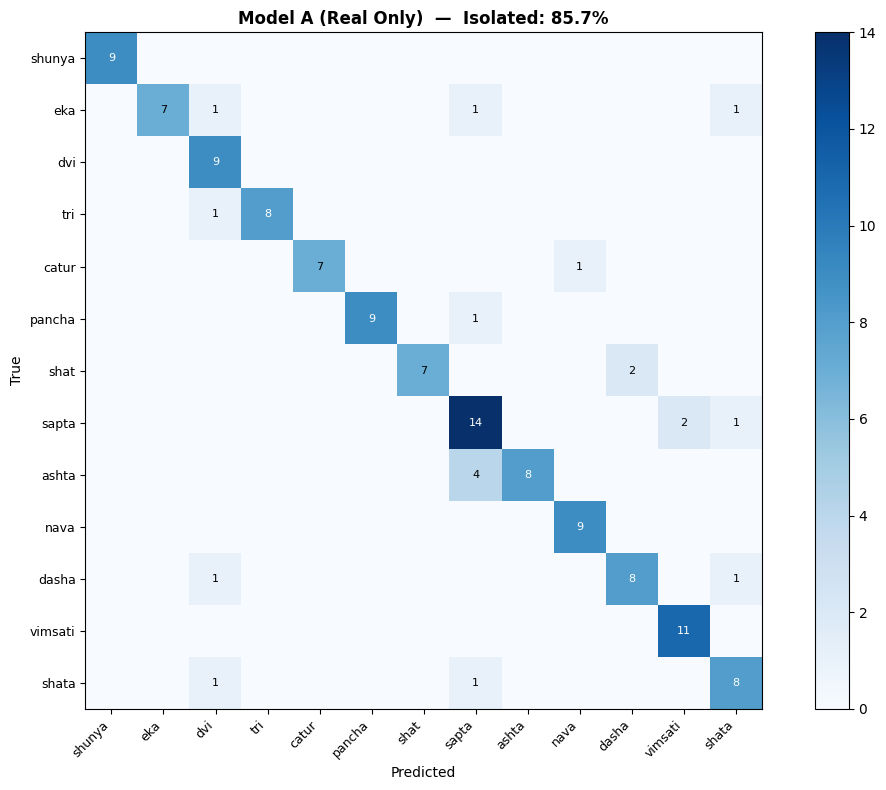

  Saved: /kaggle/working/outputs/confusion_A.png


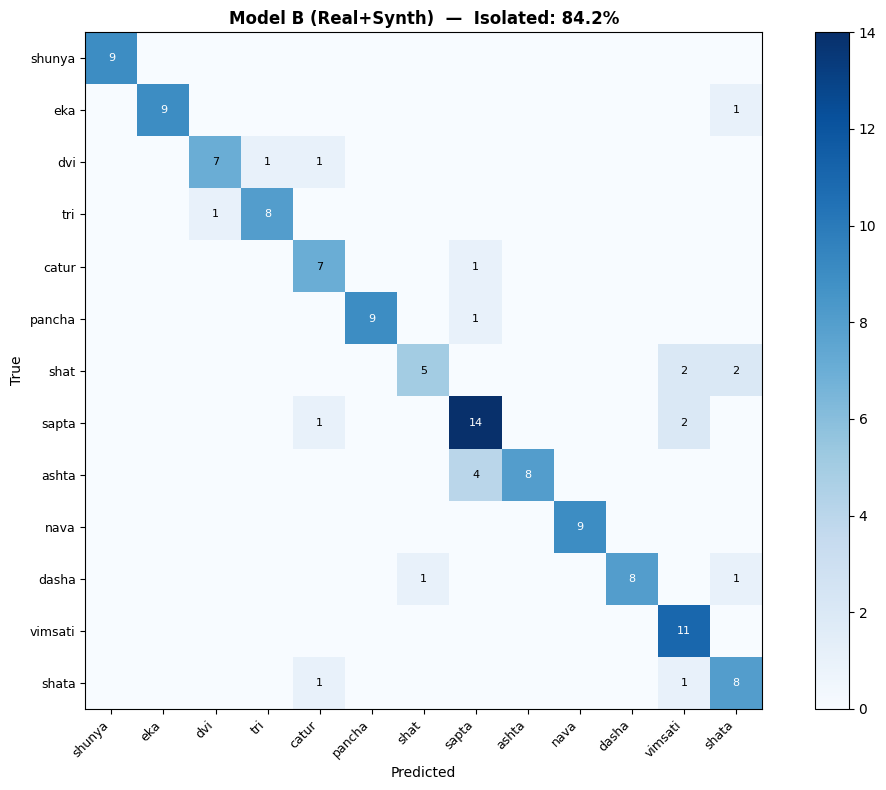

  Saved: /kaggle/working/outputs/confusion_B.png


In [17]:
def plot_confusion(confusion, title, path):
    fig, ax = plt.subplots(figsize=(11, 8))
    im = ax.imshow(confusion, cmap="Blues")
    ax.set_xticks(range(len(VOCAB)))
    ax.set_xticklabels(VOCAB, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(VOCAB)))
    ax.set_yticklabels(VOCAB, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    plt.colorbar(im, ax=ax)
    for i in range(len(VOCAB)):
        for j in range(len(VOCAB)):
            if confusion[i, j] > 0:
                ax.text(j, i, str(confusion[i, j]),
                        ha="center", va="center", fontsize=8,
                        color="white" if confusion[i,j] > confusion.max()*0.5 else "black")
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")

plot_confusion(confusion_A,
    f"Model A (Real Only)  —  Isolated: {iso_acc_A:.1f}%",
    os.path.join(OUTPUT_DIR, "confusion_A.png"))

plot_confusion(confusion_B,
    f"Model B (Real+Synth)  —  Isolated: {iso_acc_B:.1f}%",
    os.path.join(OUTPUT_DIR, "confusion_B.png"))


## Step 17: Summary Report and Comparison Chart

  FINAL REPORT
  Metric                                      A         B
  ----------------------------------------------------
  Training samples (real aug)             5,796     5,796
  Training samples (synth aug)                0       819
  Isolated accuracy                       85.7%     84.2%
  Compound accuracy                       82.0%     73.0%
  ----------------------------------------------------
  Winner: Model A

  Token          Iso A   Iso B
  shunya         100.0%   100.0%
  eka             70.0%    90.0%
  dvi            100.0%    77.8% *
  tri             88.9%    88.9%
  catur           87.5%    87.5%
  pancha          90.0%    90.0%
  shat            77.8%    55.6% *
  sapta           82.4%    82.4%
  ashta           66.7%    66.7%
  nava           100.0%   100.0%
  dasha           80.0%    80.0%
  vimsati        100.0%   100.0%
  shata           80.0%    80.0%


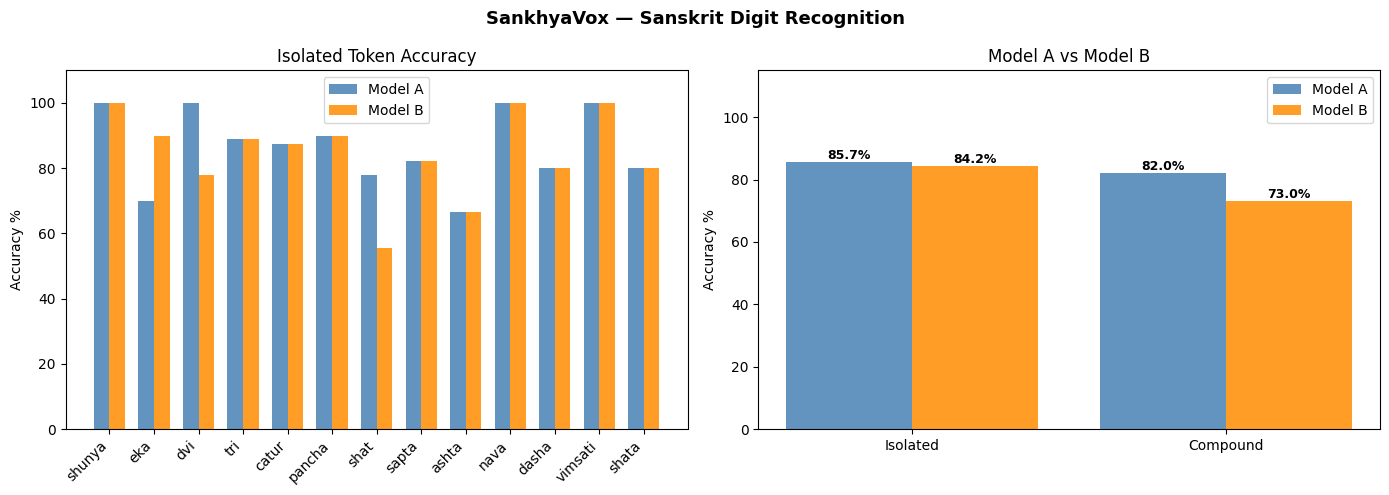

Chart saved: /kaggle/working/outputs/comparison.png


In [18]:
print("=" * 55)
print("  FINAL REPORT")
print("=" * 55)
print(f"  {'Metric':35s}  {'A':>8}  {'B':>8}")
print(f"  {'-'*52}")
print(f"  {'Training samples (real aug)':35s}  {sum(len(v) for v in features_real.values()):>8,}  {sum(len(v) for v in features_real.values()):>8,}")
print(f"  {'Training samples (synth aug)':35s}  {'0':>8}  {sum(len(v) for v in features_both.values())-sum(len(v) for v in features_real.values()):>8,}")
print(f"  {'Isolated accuracy':35s}  {iso_acc_A:>7.1f}%  {iso_acc_B:>7.1f}%")
print(f"  {'Compound accuracy':35s}  {comp_acc_A:>7.1f}%  {comp_acc_B:>7.1f}%")
print(f"  {'-'*52}")
print(f"  Winner: Model {winner_label}")
print()
print(f"  {'Token':12s}  {'Iso A':>6}  {'Iso B':>6}")
for tok in VOCAB:
    a = results_A.get(tok,{}).get("acc",0)
    b = results_B.get(tok,{}).get("acc",0)
    mark = " *" if (winner_label=="B" and b>a) or (winner_label=="A" and a>b) else ""
    print(f"  {tok:12s}  {a:6.1f}%  {b:6.1f}%{mark}")

# Comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(VOCAB))
w = 0.35
a_iso = [results_A.get(t,{}).get("acc",0) for t in VOCAB]
b_iso = [results_B.get(t,{}).get("acc",0) for t in VOCAB]
axes[0].bar(x - w/2, a_iso, w, label="Model A", color="steelblue",  alpha=0.85)
axes[0].bar(x + w/2, b_iso, w, label="Model B", color="darkorange", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(VOCAB, rotation=45, ha="right")
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Accuracy %")
axes[0].set_title("Isolated Token Accuracy")
axes[0].legend()

cats  = ["Isolated", "Compound"]
a_v   = [iso_acc_A, comp_acc_A]
b_v   = [iso_acc_B, comp_acc_B]
x2    = np.arange(len(cats))
axes[1].bar(x2 - 0.2, a_v, 0.4, label="Model A", color="steelblue",  alpha=0.85)
axes[1].bar(x2 + 0.2, b_v, 0.4, label="Model B", color="darkorange", alpha=0.85)
for i,(a,b) in enumerate(zip(a_v, b_v)):
    axes[1].text(i-0.2, a+1, f"{a:.1f}%", ha="center", fontsize=9, fontweight="bold")
    axes[1].text(i+0.2, b+1, f"{b:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(cats)
axes[1].set_ylim(0, 115)
axes[1].set_ylabel("Accuracy %")
axes[1].set_title("Model A vs Model B")
axes[1].legend()

plt.suptitle("SankhyaVox — Sanskrit Digit Recognition", fontsize=13, fontweight="bold")
plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, "comparison.png")
plt.savefig(chart_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")


## Step 18: Inference Wrapper

In [19]:
class SankhyaVoxInference:
    def __init__(self, hmm_bank, decoder, vocab, grammar, devanagari):
        self.hmm_bank   = hmm_bank
        self.decoder    = decoder
        self.vocab      = vocab
        self.grammar    = grammar
        self.devanagari = devanagari

    @classmethod
    def load(cls, model_dir):
        with open(os.path.join(model_dir, "config.json"), encoding="utf-8") as f:
            cfg = json.load(f)
        vocab_   = cfg["vocab"]
        grammar_ = {int(k): v for k, v in cfg["grammar"].items()}
        dev_     = cfg["devanagari"]
        bank     = SankhyaHMM(vocab_)
        bank.load(model_dir)
        dec = SegmentClassifyDecoder(bank, vocab=vocab_, grammar=grammar_)
        return cls(bank, dec, vocab_, grammar_, dev_)

    def predict_audio(self, audio, sr=SAMPLE_RATE, verbose=False):
        audio  = preprocess_audio(audio.astype("float32"), sr)
        number, tokens, debug = self.decoder.decode(audio, sr=sr, verbose=verbose)
        gaps = debug.get("gaps", [0.0])
        conf = min(1.0, max(0.0, float(np.mean(gaps)) / 5.0)) if gaps else 0.0
        return {
            "number":     number,
            "tokens":     tokens,
            "devanagari": [self.devanagari.get(t, t) for t in tokens],
            "confidence": round(conf, 3),
            "success":    number >= 0,
        }

    def predict_file(self, path, verbose=False):
        audio, sr = load_audio(path)
        return self.predict_audio(audio, sr, verbose=verbose)

# Instantiate both
inf_A = SankhyaVoxInference(hmm_bank_A, decoder_A, VOCAB, GRAMMAR, DEVANAGARI)
inf_B = SankhyaVoxInference(hmm_bank_B, decoder_B, VOCAB, GRAMMAR, DEVANAGARI)

print("Inference wrappers ready: inf_A, inf_B")

# Smoke test
print("\nSmoke test:")
for tok in ["pancha", "dasha", "vimsati"]:
    clips = real_audio.get(tok, [])
    if clips:
        audio, sr = clips[0]
        r = inf_A.predict_audio(audio, sr)
        expected = tokens_to_number([tok])
        status = "ok" if r["number"] == expected else f"WRONG (got {r['number']})"
        print(f"  {tok}: {status}")


Inference wrappers ready: inf_A, inf_B

Smoke test:
  pancha: ok
  dasha: WRONG (got 2)
  vimsati: ok


## Step 19: Save Model Packages

In [20]:
def save_package(hmm_bank, decoder, per_token, iso_acc, comp_acc,
                 train_log, model_dir, label):
    os.makedirs(model_dir, exist_ok=True)

    cfg = {
        "label":       label,
        "vocab":       VOCAB,
        "devanagari":  DEVANAGARI,
        "grammar":     {str(k): v for k, v in GRAMMAR.items()},
        "hmm_config":  {tok: list(v) for tok, v in HMM_CONFIG.items()},
        "sample_rate": SAMPLE_RATE,
        "n_features":  N_FEATURES,
        "vad_top_db":  SegmentClassifyDecoder.VAD_TOP_DB,
        "vad_min_dur_s": SegmentClassifyDecoder.VAD_MIN_DUR_S,
        "vad_max_segs":  SegmentClassifyDecoder.VAD_MAX_SEGS,
        "eval_gap_ms":   EVAL_GAP_MS,
    }
    with open(os.path.join(model_dir, "config.json"), "w", encoding="utf-8") as f:
        json.dump(cfg, f, indent=2, ensure_ascii=False)

    report = {
        "label":              label,
        "isolated_accuracy":  round(iso_acc, 2),
        "compound_accuracy":  round(comp_acc, 2),
        "per_token": {
            tok: {"acc": round(v.get("acc",0),2), "n": v.get("n",0)}
            for tok, v in per_token.items()
        },
        "train_log": {
            tok: {k: (float(v) if isinstance(v, (np.floating,)) else v)
                  for k, v in info.items()}
            for tok, info in train_log.items()
        },
    }
    with open(os.path.join(model_dir, "eval_report.json"), "w") as f:
        json.dump(report, f, indent=2)

    hmm_bank.save(model_dir)

    for fname in ["comparison.png", "confusion_A.png", "confusion_B.png"]:
        src = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(model_dir, fname))

    print(f"  Saved: {model_dir}")

print("Saving Model A:")
save_package(hmm_bank_A, decoder_A, results_A, iso_acc_A, comp_acc_A,
             train_log_A, MODEL_A_DIR, "model_A_real_only")

print("Saving Model B:")
save_package(hmm_bank_B, decoder_B, results_B, iso_acc_B, comp_acc_B,
             train_log_B, MODEL_B_DIR, "model_B_real_synth")

print("Saving winner:")
shutil.copytree(winner_dir, BEST_DIR, dirs_exist_ok=True)
with open(os.path.join(BEST_DIR, "winner.json"), "w") as f:
    json.dump({"winner": winner_label, "isolated": winner_iso,
               "compound": winner_comp, "source_dir": winner_dir}, f, indent=2)
print(f"  Winner (Model {winner_label}) -> {BEST_DIR}")


Saving Model A:
  13 models saved to /kaggle/working/model_A_real_only
  Saved: /kaggle/working/model_A_real_only
Saving Model B:
  13 models saved to /kaggle/working/model_B_real_synth
  Saved: /kaggle/working/model_B_real_synth
Saving winner:
  Winner (Model A) -> /kaggle/working/model_best


## Step 20: Package for Download

In [21]:
def zip_dir(src, dst):
    try:
        with zipfile.ZipFile(dst, "w", zipfile.ZIP_DEFLATED) as zf:
            for f in Path(src).rglob("*"):
                if f.is_file():
                    zf.write(f, f.relative_to(src))
        mb = os.path.getsize(dst) / 1e6
        print(f"  {os.path.basename(dst)}  ({mb:.1f} MB)")
    except Exception as e:
        print(f"  ZIP failed for {dst}: {e}")

zip_dir(MODEL_A_DIR, os.path.join(WORKING_DIR, "sankhyavox_model_A.zip"))
zip_dir(MODEL_B_DIR, os.path.join(WORKING_DIR, "sankhyavox_model_B.zip"))
zip_dir(BEST_DIR,    os.path.join(WORKING_DIR, "sankhyavox_best.zip"))
print("\nDownload from Kaggle Output tab: sankhyavox_best.zip")
print("Load on your server:")
print("  inf = SankhyaVoxInference.load('models/best/')")
print("  result = inf.predict_file('speech.wav')")


  sankhyavox_model_A.zip  (0.3 MB)
  sankhyavox_model_B.zip  (0.3 MB)
  sankhyavox_best.zip  (0.3 MB)

Download from Kaggle Output tab: sankhyavox_best.zip
Load on your server:
  inf = SankhyaVoxInference.load('models/best/')
  result = inf.predict_file('speech.wav')


## Step 21: Flask Server Template

In [22]:
FLASK_TEMPLATE = '''#!/usr/bin/env python3
"""
SankhyaVox Flask server.

Usage:
    python app.py
    curl -X POST http://localhost:5000/predict -F "file=@recording.wav"

Endpoints:
    POST /predict        predict with best model
    GET  /health         status check
    GET  /info           model metadata and accuracy
"""
import os, json, tempfile
from flask import Flask, request, jsonify

app = Flask(__name__)
MODEL_DIR = "models/best"

print("Loading model...")
model = SankhyaVoxInference.load(MODEL_DIR)
print("Ready.")

@app.route("/predict", methods=["POST"])
def predict():
    if "file" not in request.files:
        return jsonify({"error": "No file. Send audio as form-data key 'file'."}), 400
    f      = request.files["file"]
    suffix = "." + f.filename.rsplit(".", 1)[-1].lower()
    with tempfile.NamedTemporaryFile(suffix=suffix, delete=False) as tmp:
        f.save(tmp.name)
        try:
            result = model.predict_file(tmp.name)
        except Exception as e:
            return jsonify({"error": str(e)}), 500
        finally:
            os.unlink(tmp.name)
    return jsonify(result)

@app.route("/health")
def health():
    return jsonify({"status": "ok"})

@app.route("/info")
def info():
    rp = os.path.join(MODEL_DIR, "eval_report.json")
    report = json.load(open(rp)) if os.path.exists(rp) else {}
    return jsonify(report)

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''

flask_path = os.path.join(WORKING_DIR, "app.py")
with open(flask_path, "w") as f:
    f.write(FLASK_TEMPLATE)
print(f"Flask template saved: {flask_path}")


Flask template saved: /kaggle/working/app.py


## Step 22: Live Verification

In [23]:
TEST_WAV = None  # set to a .wav path to test a real file

print("Verification (using best model):")
inf_best = SankhyaVoxInference(winner_bank, winner_decoder, VOCAB, GRAMMAR, DEVANAGARI)

test_targets = [0, 5, 10, 15, 20, 21, 42, 57, 99]
print(f"  {'Target':>6}  {'Sequence':35s}  {'Predicted':>9}  {'Gap ms':>6}")
print(f"  {'-'*62}")
for target in test_targets:
    seq = GRAMMAR[target]
    audio, sr = build_compound(seq, winner_bank, gap_ms=EVAL_GAP_MS)
    if audio is None:
        print(f"  {target:6d}  {str(seq):35s}  no clip")
        continue
    audio = preprocess_audio(audio, sr)
    r = inf_best.predict_audio(audio, sr)
    status = "ok" if r["number"] == target else f"WRONG"
    print(f"  {target:6d}  {str(seq):35s}  {r['number']:9d}  {r['confidence']:6.3f}  {status}")

if TEST_WAV and os.path.exists(TEST_WAV):
    print(f"\nUser file: {TEST_WAV}")
    r = inf_best.predict_file(TEST_WAV, verbose=True)
    print(f"Result: {r}")
elif TEST_WAV:
    print(f"File not found: {TEST_WAV}")


Verification (using best model):
  Target  Sequence                             Predicted  Gap ms
  --------------------------------------------------------------
       0  ['shunya']                                   0   1.000  ok
       5  ['pancha']                                   5   1.000  ok
      10  ['dasha']                                   10   0.883  ok
      15  ['dasha', 'pancha']                         15   1.000  ok
      20  ['vimsati']                                 20   1.000  ok
      21  ['vimsati', 'eka']                          21   1.000  ok
      42  ['catur', 'dasha', 'dvi']                   62   0.585  WRONG
      57  ['pancha', 'dasha', 'sapta']                57   0.946  ok
      99  ['nava', 'dasha', 'nava']                   99   0.700  ok
